 <h1>

 Airbnb Price Prediction Project

 </h1>

 <h3>

 1) Problem Statement

 </h3>

 <p>

 The goal of this project is to predict Airbnb listing prices using structured listing data such as

 location, room type, review scores, host information, and availability.

 This notebook demonstrates a complete machine learning workflow, including data loading,

 exploratory analysis, data cleaning, feature engineering, model building, hyperparameter tuning,

 evaluation, and interpretation.

 </p>

In [45]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")


 <h3>

 2) Data Loading

 </h3>

 <p>

 In this section, Airbnb listings from Columbus, Nashville, and Prague are loaded and combined.

 The Prague dataset is converted from Czech koruna to U.S. dollars so that all cities use the same

 currency scale.

 </p>

In [46]:
# =========================================
# 2. LOAD AND COMBINE MULTIPLE CITY DATASETS
# =========================================
CZK_TO_USD = 0.0485

def clean_price_column(series):
    cleaned = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("Kč", "", regex=False)
        .str.replace("CZK", "", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")

# Columbus
columbus = pd.read_csv("listings.csv/listings - Columbus, Ohio.csv")
columbus["city"] = "Columbus"
columbus["price"] = clean_price_column(columbus["price"])

# Nashville
nashville = pd.read_csv("listings.csv/listings - Nashville, Tennessee.csv")
nashville["city"] = "Nashville"
nashville["price"] = clean_price_column(nashville["price"])

# Austin
austin = pd.read_csv("listings.csv/listings - Austin, Texas.csv")
austin["city"] = "Austin"
austin["price"] = clean_price_column(austin["price"])

# Chicago
chicago = pd.read_csv("listings.csv/listings - Chicago, Illinois.csv")
chicago["city"] = "Chicago"
chicago["price"] = clean_price_column(chicago["price"])

# Prague
prague = pd.read_csv("listings.csv/listings - Prague, Czech Republic.csv")
prague["city"] = "Prague"
prague["price"] = clean_price_column(prague["price"])
prague["price"] = prague["price"] * CZK_TO_USD

# Combine all datasets
df = pd.concat([columbus, nashville, prague, austin, chicago], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nRows by city:")
print(df["city"].value_counts())

print("\nAverage price by city after conversion:")
print(df.groupby("city")["price"].mean().sort_values(ascending=False))

print("\nMissing share by city:")
print(df.groupby("city")["price"].apply(lambda x: x.isna().mean()))


Combined dataset shape: (42350, 81)

Rows by city:
city
Prague       10834
Austin       10533
Nashville     9443
Chicago       8663
Columbus      2877
Name: count, dtype: int64

Average price by city after conversion:
city
Chicago      601.126980
Austin       414.537701
Columbus     327.461024
Nashville    223.399608
Prague       194.493967
Name: price, dtype: float64

Missing share by city:
city
Austin       0.001519
Chicago      0.096387
Columbus     0.063608
Nashville    0.297469
Prague       0.123315
Name: price, dtype: float64


 <h3>

 3) Data Exploration

 </h3>

 <p>

 This section explores the structure of the dataset, missing values, and the distribution of prices.

 The plots help justify later preprocessing choices such as outlier handling and log transformation.

 </p>

Dataset shape: (42350, 81)

City counts before cleaning:
city
Prague       10834
Austin       10533
Nashville     9443
Chicago       8663
Columbus      2877
Name: count, dtype: int64

Top missing values:
neighbourhood_group_cleansed    42350
calendar_updated                42350
neighbourhood_group             42350
neighborhood_overview           40838
host_about                      40475
host_location                   40075
review_scores_rating            39792
review_scores_location          39792
first_review                    39792
review_scores_accuracy          39792
review_scores_cleanliness       39792
review_scores_checkin           39792
review_scores_communication     39792
review_scores_value             39792
host_neighbourhood              39680
bathrooms                       39657
estimated_revenue_l365d         39656
beds                            39656
host_response_time              39647
host_response_rate              39647
dtype: int64

Price summary statisti

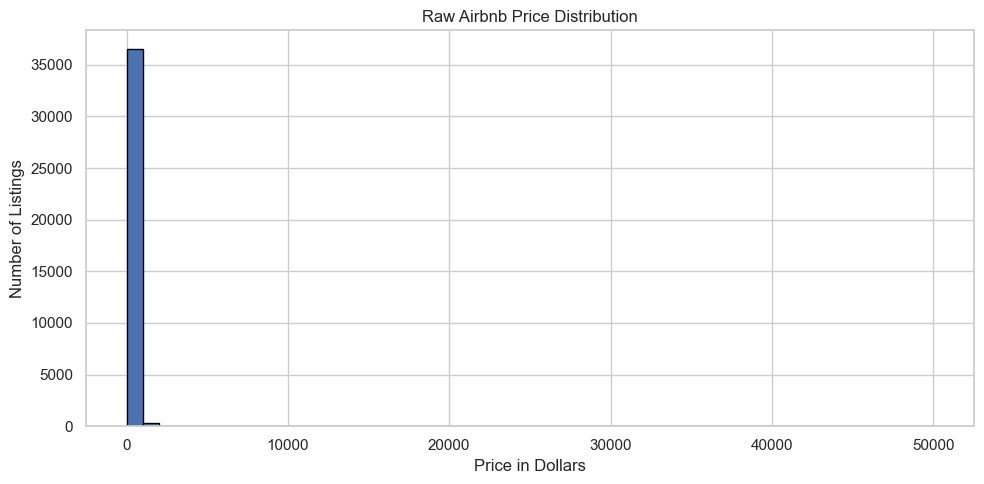

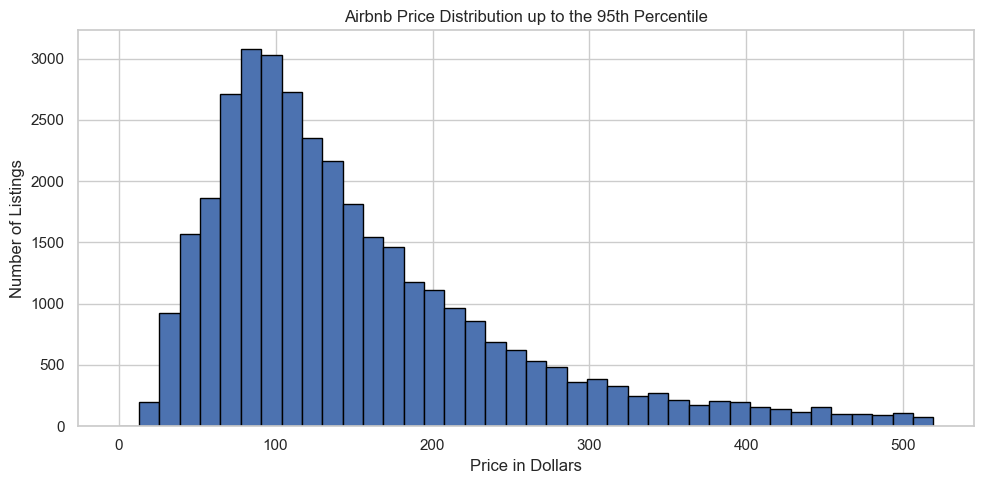

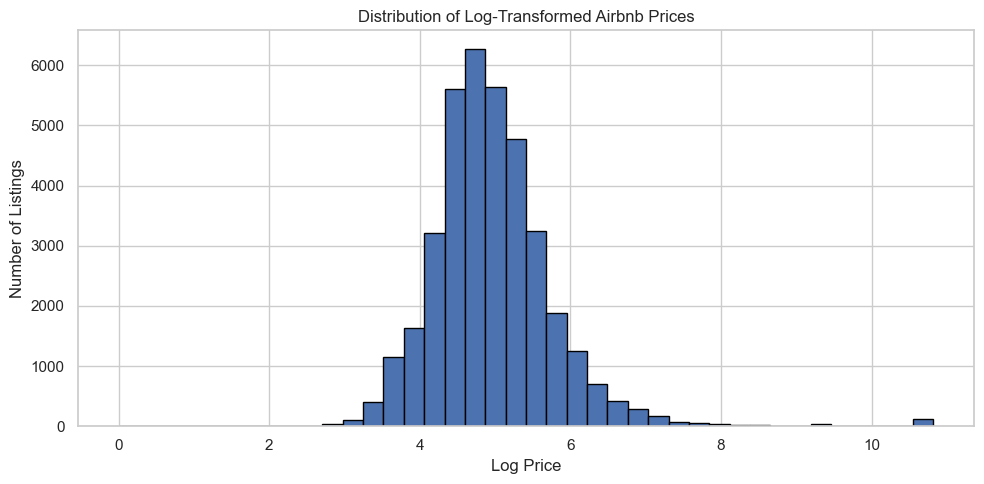

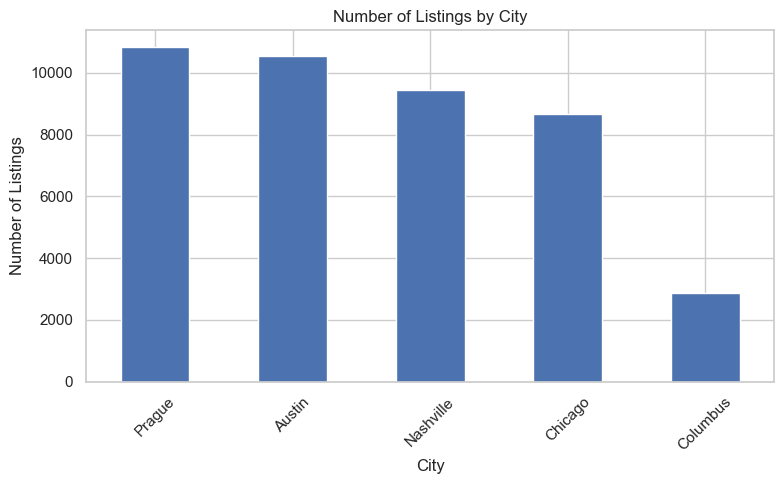

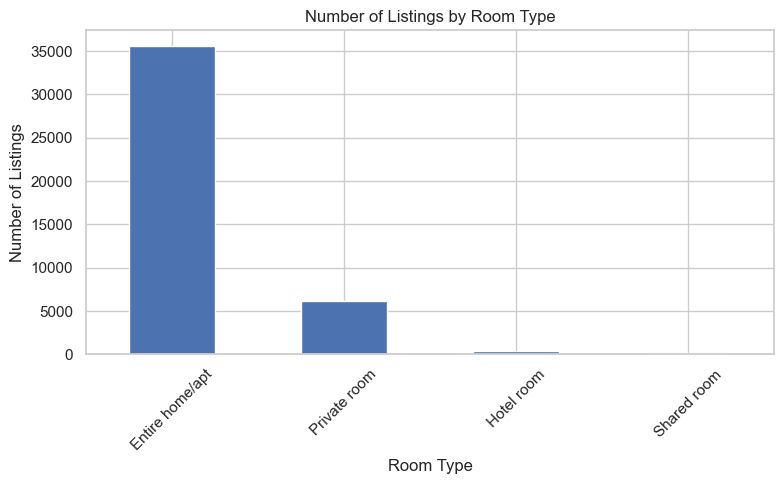

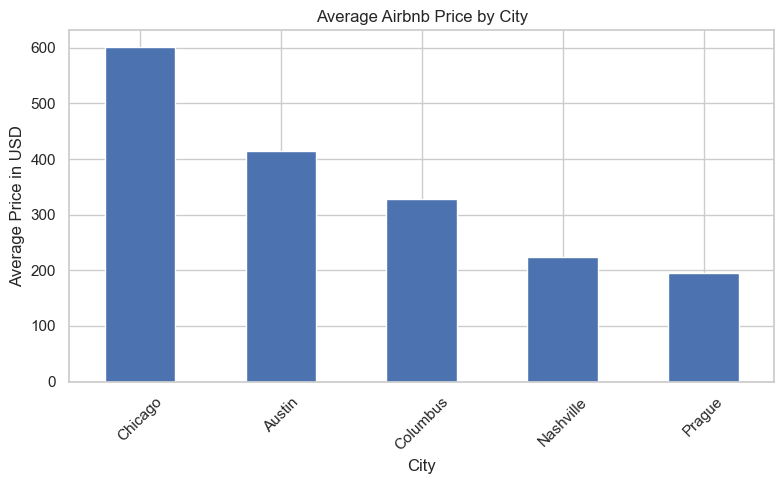

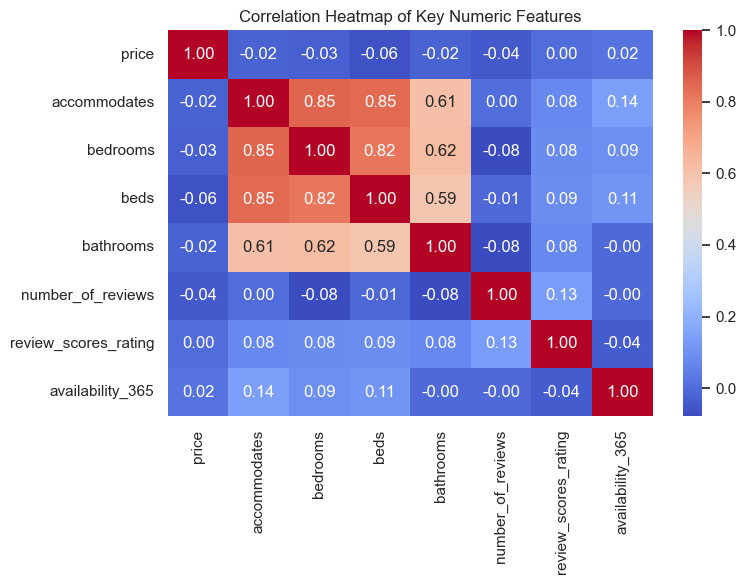

In [47]:
# =========================================
# 3. DATA EXPLORATION
# =========================================
print("Dataset shape:", df.shape)

print("\nCity counts before cleaning:")
print(df["city"].value_counts())

print("\nTop missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nPrice summary statistics:")
print(df["price"].describe())

print("\nAverage price by city:")
print(df.groupby("city")["price"].mean().sort_values(ascending=False))

print("\nTop 10 most expensive listings:")
print(df["price"].sort_values(ascending=False).head(10))

# Raw price histogram
plt.figure(figsize=(10, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Price in Dollars")
plt.ylabel("Number of Listings")
plt.title("Raw Airbnb Price Distribution")
plt.tight_layout()
plt.show()

# Global 95th percentile view for readability only
price_95 = df["price"].quantile(0.95)

plt.figure(figsize=(10, 5))
plt.hist(df.loc[df["price"] <= price_95, "price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Price in Dollars")
plt.ylabel("Number of Listings")
plt.title("Airbnb Price Distribution up to the 95th Percentile")
plt.tight_layout()
plt.show()

# Log-price exploration
log_price = np.log1p(df["price"])

plt.figure(figsize=(10, 5))
plt.hist(log_price.dropna(), bins=40, edgecolor="black")
plt.xlabel("Log Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.tight_layout()
plt.show()

# Listings by city
plt.figure(figsize=(8, 5))
df["city"].value_counts().plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Number of Listings")
plt.title("Number of Listings by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Listings by room type
if "room_type" in df.columns:
    plt.figure(figsize=(8, 5))
    df["room_type"].value_counts().plot(kind="bar")
    plt.xlabel("Room Type")
    plt.ylabel("Number of Listings")
    plt.title("Number of Listings by Room Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Average price by city
city_avg_price = df.groupby("city")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
city_avg_price.plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Average Price in USD")
plt.title("Average Airbnb Price by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap
candidate_cols = [
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "review_scores_rating",
    "availability_365"
]
existing_cols = [col for col in candidate_cols if col in df.columns]

if len(existing_cols) > 1:
    plt.figure(figsize=(8, 6))
    corr = df[existing_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap of Key Numeric Features")
    plt.tight_layout()
    plt.show()


 <h3>

 4) Data Cleaning

 </h3>

 <p>

 The target variable is cleaned by removing missing values and filtering extreme outliers within each

 city. A log transformation is then applied to stabilize the target distribution.

 </p>

Dataset shape after per-city 95 percent cutoff: (35309, 81)

City counts after cleaning:
city
Austin       9991
Prague       9023
Chicago      7436
Nashville    6301
Columbus     2558
Name: count, dtype: int64


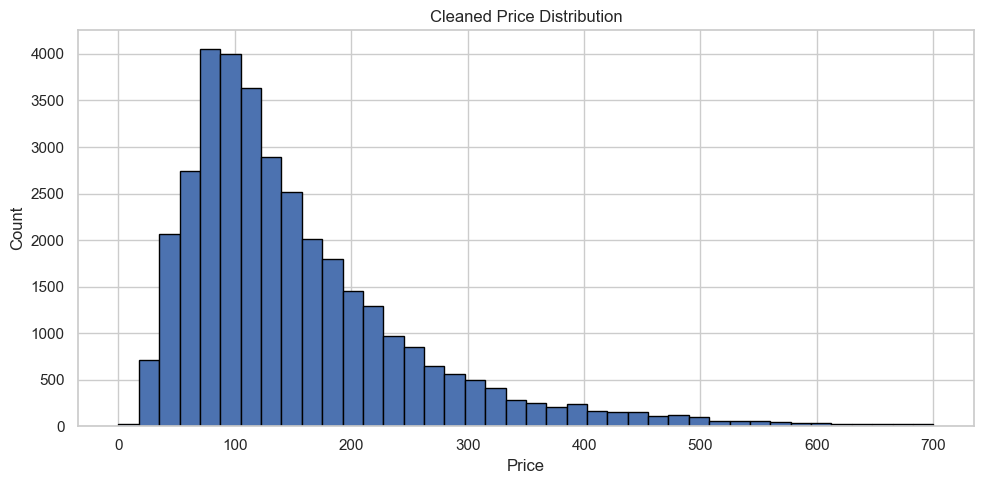

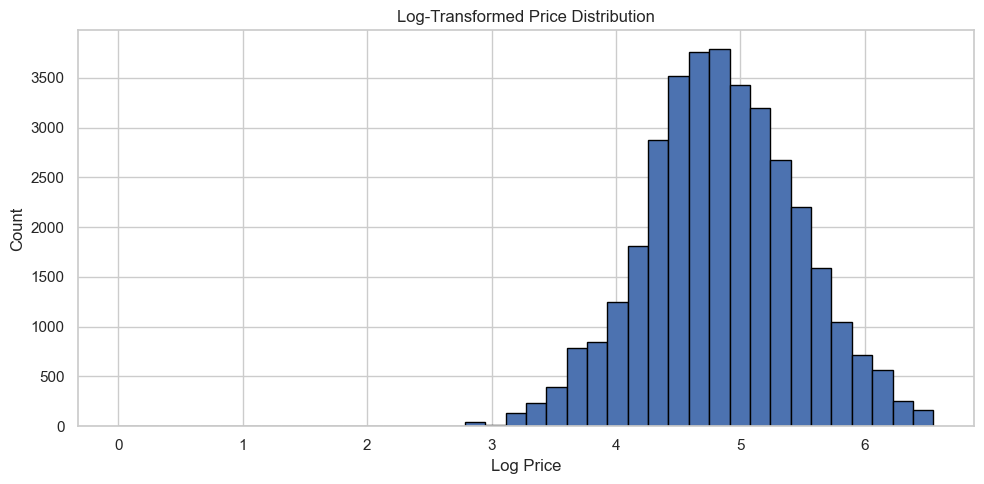

In [48]:
# =========================================
# 4. CLEAN TARGET VARIABLE
# =========================================
df = df.dropna(subset=["price"]).copy()

# Remove top 5 percent within each city
df = df[df["price"] < df.groupby("city")["price"].transform(lambda x: x.quantile(0.95))].copy()

print("Dataset shape after per-city 95 percent cutoff:", df.shape)
print("\nCity counts after cleaning:")
print(df["city"].value_counts())

# Log-transform target
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(10, 5))
plt.hist(df["price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Cleaned Price Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["log_price"].dropna(), bins=40, edgecolor="black")
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.title("Log-Transformed Price Distribution")
plt.tight_layout()
plt.show()


 <h3>

 5) Feature Engineering

 </h3>

 <p>

 New features are created from dates, listing characteristics, review activity, and location patterns

 to improve model performance.

 </p>

In [49]:
# =========================================
# 5. DATETIME FEATURES
# =========================================
date_cols = ["host_since", "first_review", "last_review", "last_scraped", "calendar_last_scraped"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

reference_date = df["last_scraped"].max() if "last_scraped" in df.columns else pd.Timestamp.today()

if "host_since" in df.columns:
    df["host_tenure_days"] = (reference_date - df["host_since"]).dt.days

if "first_review" in df.columns:
    df["days_since_first_review"] = (reference_date - df["first_review"]).dt.days

if "last_review" in df.columns:
    df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days


In [52]:
# =========================================
# 6. FEATURE ENGINEERING
# =========================================

# Convert percentage columns
for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("%", "", regex=False)
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert boolean-style columns
bool_map = {"t": 1, "f": 0, True: 1, False: 0}
for col in [
    "instant_bookable",
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "has_availability"
]:
    if col in df.columns:
        df[col] = df[col].map(bool_map)

# Extract numeric bathrooms from text
if "bathrooms_text" in df.columns:
    df["bathrooms_text_num"] = (
        df["bathrooms_text"]
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

# Count amenities
if "amenities" in df.columns:
    def count_amenities(x):
        try:
            return len(ast.literal_eval(x))
        except Exception:
            return np.nan

    df["amenities_count"] = df["amenities"].apply(count_amenities)

# Distance from real city centers
if "latitude" in df.columns and "longitude" in df.columns and "city" in df.columns:
    city_centers = {
        "Columbus": (39.9612, -82.9988),
        "Nashville": (36.1627, -86.7816),
        "Prague": (50.0755, 14.4378),
        "Chicago": (41.8781, -87.6298),
        "Austin": (30.2672, -97.7431)
    }

    def compute_distance(row):
        lat, lon = row["latitude"], row["longitude"]
        center_lat, center_lon = city_centers[row["city"]]
        return np.sqrt((lat - center_lat) ** 2 + (lon - center_lon) ** 2)

    df["distance_to_city_center"] = df.apply(compute_distance, axis=1)

# Safe engineered features
if "bedrooms" in df.columns and "accommodates" in df.columns:
    df["bedroom_density"] = df["bedrooms"] / (df["accommodates"] + 1)

if "beds" in df.columns and "accommodates" in df.columns:
    df["bed_density"] = df["beds"] / (df["accommodates"] + 1)

if "beds" in df.columns and "bedrooms" in df.columns:
    df["beds_per_bedroom"] = df["beds"] / (df["bedrooms"] + 1)

if "availability_365" in df.columns:
    df["availability_ratio"] = df["availability_365"] / 365

if "number_of_reviews" in df.columns and "host_listings_count" in df.columns:
    df["reviews_per_listing"] = df["number_of_reviews"] / (df["host_listings_count"] + 1)

if "reviews_per_month" in df.columns and "host_listings_count" in df.columns:
    df["reviews_per_month_per_listing"] = df["reviews_per_month"] / (df["host_listings_count"] + 1)

if "number_of_reviews" in df.columns and "host_tenure_days" in df.columns:
    df["reviews_per_day"] = df["number_of_reviews"] / (df["host_tenure_days"] + 1)

if "availability_365" in df.columns and "number_of_reviews" in df.columns:
    df["availability_per_review"] = df["availability_365"] / (df["number_of_reviews"] + 1)

if "accommodates" in df.columns and "bedrooms" in df.columns:
    df["accommodates_x_bedrooms"] = df["accommodates"] * df["bedrooms"]

if "accommodates" in df.columns and "beds" in df.columns:
    df["accommodates_x_beds"] = df["accommodates"] * df["beds"]

if "number_of_reviews" in df.columns:
    df["log_number_of_reviews"] = np.log1p(df["number_of_reviews"])

if "minimum_nights" in df.columns:
    df["log_minimum_nights"] = np.log1p(df["minimum_nights"])

# Better per-city location clustering
if "latitude" in df.columns and "longitude" in df.columns and "city" in df.columns:
    df["location_cluster"] = -1
    cluster_offset = 0

    for city in df["city"].unique():
        subset = df[df["city"] == city]

        kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
        labels = kmeans.fit_predict(subset[["latitude", "longitude"]])

        df.loc[subset.index, "location_cluster"] = labels + cluster_offset
        cluster_offset += 20

# Drop completely empty columns
df = df.dropna(axis=1, how="all")


 <h3>

 6) Train / Validation / Test Split

 </h3>

 <p>

 The dataset is split into train, validation, and test sets using a 60/20/20 split. Stratification

 by city keeps the city distribution balanced across splits.

 </p>

In [53]:
# =========================================
# 7. SELECT FEATURES
# =========================================
feature_cols = [
    "city",
    "accommodates",
    "bathrooms",
    "bathrooms_text_num",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "availability_eoy",
    "estimated_occupancy_l365d",
    "host_response_rate",
    "host_acceptance_rate",
    "latitude",
    "longitude",
    "distance_to_city_center",
    "host_tenure_days",
    "days_since_first_review",
    "days_since_last_review",
    "amenities_count",
    "instant_bookable",
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "has_availability",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_response_time",
    "source",
    "bedroom_density",
    "bed_density",
    "availability_ratio",
    "reviews_per_listing",
    "reviews_per_day",
    "accommodates_x_bedrooms",
    "location_cluster"
]

feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols].copy()
y = df["log_price"]

print("Number of selected features:", len(feature_cols))
print(feature_cols)


Number of selected features: 57
['city', 'accommodates', 'bathrooms', 'bathrooms_text_num', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'reviews_per_month', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'estimated_occupancy_l365d', 'host_response_rate', 'host_acceptance_rate', 'latitude', 'longitude', 'distance_to_city_center', 'host_tenure_days', 'days_since_first_review', 'days_since_last_review', 'amenities_count', 'instant_bookable', 'host_is_su

In [54]:
# =========================================
# 8. TRAIN / DEV / TEST SPLIT
# =========================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=X["city"] if "city" in X.columns else None
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=X_train_full["city"] if "city" in X_train_full.columns else None
)

print("Train shape:", X_train.shape)
print("Dev shape:", X_dev.shape)
print("Test shape:", X_test.shape)

if "city" in X.columns:
    print("\nCity distribution in Train:")
    print(X_train["city"].value_counts(normalize=True))
    print("\nCity distribution in Dev:")
    print(X_dev["city"].value_counts(normalize=True))
    print("\nCity distribution in Test:")
    print(X_test["city"].value_counts(normalize=True))


Train shape: (21185, 57)
Dev shape: (7062, 57)
Test shape: (7062, 57)

City distribution in Train:
city
Austin       0.282983
Prague       0.255511
Chicago      0.210621
Nashville    0.178475
Columbus     0.072410
Name: proportion, dtype: float64

City distribution in Dev:
city
Austin       0.282923
Prague       0.255593
Chicago      0.210564
Nashville    0.178420
Columbus     0.072501
Name: proportion, dtype: float64

City distribution in Test:
city
Austin       0.282923
Prague       0.255593
Chicago      0.210564
Nashville    0.178420
Columbus     0.072501
Name: proportion, dtype: float64


In [69]:
# =========================================
# TRAIN-ONLY CITY AVERAGE PRICE FEATURE
# =========================================

train_df = X_train.copy()
train_df["price"] = np.expm1(y_train)

city_avg = train_df.groupby("city")["price"].mean()

X_train["city_avg_price"] = X_train["city"].map(city_avg)
X_dev["city_avg_price"] = X_dev["city"].map(city_avg)
X_test["city_avg_price"] = X_test["city"].map(city_avg)

print("\nCity average price learned from training data:")
print(city_avg)


City average price learned from training data:
city
Austin       165.563303
Chicago      173.590318
Columbus     117.516297
Nashville    173.354668
Prague       114.973779
Name: price, dtype: float64


 <h3>

 7) Modeling

 </h3>

 <p>

 Multiple models are compared, including a simple baseline, Ridge Regression, Random Forest, and

 Gradient Boosting. This helps determine whether more flexible models outperform simpler ones.

 </p>

In [70]:
# =========================================
# 9. PREPROCESSING PIPELINE
# =========================================
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in X.columns if col not in numeric_cols]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


In [71]:
# =========================================
# 10. BASELINE AND MULTIPLE MODELS
# =========================================
baseline_pred_log = np.full(shape=len(y_dev), fill_value=y_train.mean())
baseline_mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(baseline_pred_log))
print("Baseline MAE in dollars:", baseline_mae_dollars)

models = {
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=300,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=400,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8
    )
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_dev)

    mae_log = mean_absolute_error(y_dev, preds)
    mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(preds))
    r2 = r2_score(y_dev, preds)

    results.append({
        "Model": name,
        "MAE_log": mae_log,
        "MAE_dollars": mae_dollars,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("MAE_dollars")
print(results_df)


Baseline MAE in dollars: 72.89167659395144
              Model   MAE_log  MAE_dollars        R2
1      RandomForest  0.307275    50.100313  0.569167
2  GradientBoosting  0.323226    52.061733  0.543384
0             Ridge  0.396183    61.358221  0.339110


 <h3>

 8) Hyperparameter Tuning

 </h3>

 <p>

 The strongest tree-based models are tuned using RandomizedSearchCV to improve predictive performance.

 </p>

In [72]:
# =========================================
# 11. RANDOM FOREST HYPERPARAMETER TUNING
# =========================================
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [15, 20, 25, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=12,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_full, y_train_full)

print("Best Random Forest params:")
print(rf_search.best_params_)

best_model = rf_search.best_estimator_


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 25}


In [73]:
# =========================================
# 12. XGBOOST MODEL
# =========================================
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)

xgb_dev_preds = xgb_pipe.predict(X_dev)

xgb_dev_mae_log = mean_absolute_error(y_dev, xgb_dev_preds)
xgb_dev_mae_dollars = mean_absolute_error(np.expm1(y_dev), np.expm1(xgb_dev_preds))
xgb_dev_r2 = r2_score(y_dev, xgb_dev_preds)

print("XGBoost Dev Results")
print("MAE (log):", xgb_dev_mae_log)
print("MAE (dollars):", xgb_dev_mae_dollars)
print("R2:", xgb_dev_r2)


XGBoost Dev Results
MAE (log): 0.3182961809835987
MAE (dollars): 51.383502082524366
R2: 0.554755253752468


In [74]:
# =========================================
# 13. XGBOOST HYPERPARAMETER TUNING
# =========================================
xgb_tune_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_dist = {
    "model__n_estimators": [300, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [1.0, 1.5, 2.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tune_pipe,
    param_distributions=xgb_param_dist,
    n_iter=15,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_full, y_train_full)

print("Best XGBoost params:")
print(xgb_search.best_params_)

best_xgb_model = xgb_search.best_estimator_


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGBoost params:
{'model__subsample': 0.7, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0, 'model__n_estimators': 700, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}


 <h3>

 9) Model Evaluation

 </h3>

 <p>

 Final models are evaluated on the held-out test set using MAE and R². MAE is also converted back

 to dollar units for interpretation.

 </p>

In [75]:
# =========================================
# 14. FINAL TEST EVALUATION FOR RANDOM FOREST
# =========================================
test_preds = best_model.predict(X_test)

test_mae_log = mean_absolute_error(y_test, test_preds)
test_mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(test_preds))
test_r2 = r2_score(y_test, test_preds)

print("\nFinal Test Results")
print("MAE (log):", test_mae_log)
print("MAE (dollars):", test_mae_dollars)
print("R2:", test_r2)



Final Test Results
MAE (log): 0.2870927208483683
MAE (dollars): 46.393988601877325
R2: 0.6079247867501116


In [76]:
# =========================================
# 15. FINAL TEST EVALUATION FOR XGBOOST
# =========================================
xgb_test_preds = best_xgb_model.predict(X_test)

xgb_test_mae_log = mean_absolute_error(y_test, xgb_test_preds)
xgb_test_mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(xgb_test_preds))
xgb_test_r2 = r2_score(y_test, xgb_test_preds)

print("\nFinal XGBoost Test Results")
print("MAE (log):", xgb_test_mae_log)
print("MAE (dollars):", xgb_test_mae_dollars)
print("R2:", xgb_test_r2)



Final XGBoost Test Results
MAE (log): 0.2910986468448351
MAE (dollars): 46.93243797697004
R2: 0.6032810795698529


In [77]:
# =========================================
# 16. ENSEMBLE MODEL
# =========================================
rf_preds = best_model.predict(X_test)
xgb_preds = best_xgb_model.predict(X_test)

ensemble_preds = (rf_preds * 0.5) + (xgb_preds * 0.5)

ensemble_mae = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(ensemble_preds)
)

ensemble_r2 = r2_score(y_test, ensemble_preds)

print("\nEnsemble Results")
print("MAE (dollars):", ensemble_mae)
print("R2:", ensemble_r2)



Ensemble Results
MAE (dollars): 46.111353157049784
R2: 0.6158088844438372


In [78]:
# =========================================
# 17. RELATIVE ERROR
# =========================================
mean_price = np.expm1(y_test).mean()
relative_error = ensemble_mae / mean_price

print("Mean price:", mean_price)
print("Relative error:", relative_error)


Mean price: 153.19603717077314
Relative error: 0.3009957307554098


 <h3>

 Prediction Plots

 </h3>

 <p>

 These plots compare actual and predicted prices for the final Random Forest and XGBoost models.

 A tighter pattern along the diagonal indicates stronger predictive performance.

 </p>

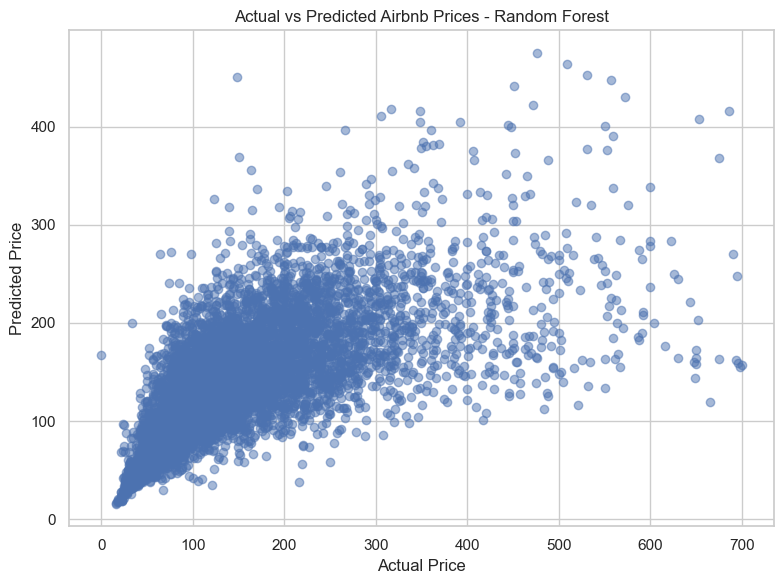

In [79]:
# =========================================
# 18. ACTUAL VS PREDICTED FOR RANDOM FOREST
# =========================================
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(test_preds)

plt.figure(figsize=(8, 6))
plt.scatter(actual_prices, predicted_prices, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices - Random Forest")
plt.tight_layout()
plt.show()


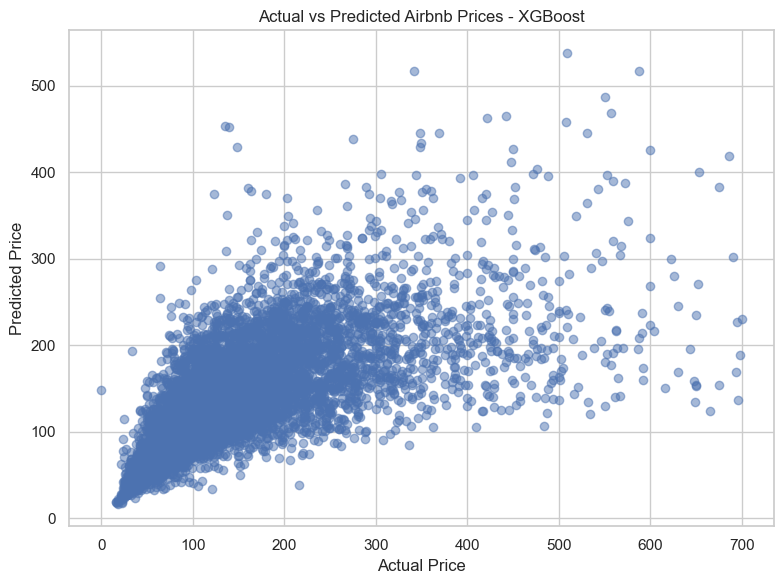

In [80]:
# =========================================
# 19. ACTUAL VS PREDICTED FOR XGBOOST
# =========================================
xgb_predicted_prices = np.expm1(xgb_test_preds)

plt.figure(figsize=(8, 6))
plt.scatter(actual_prices, xgb_predicted_prices, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices - XGBoost")
plt.tight_layout()
plt.show()


 <h3>

 10) Model Interpretation

 </h3>

 <p>

 Permutation importance is used to identify which original features most influence model performance.

 This helps explain the final model and highlights the strongest drivers of Airbnb pricing.

 </p>


Top 15 Important Features:
                           feature  importance
34                       longitude    0.451825
45                       room_type    0.439327
35         distance_to_city_center    0.175936
6                   minimum_nights    0.154435
33                        latitude    0.120000
21  calculated_host_listings_count    0.076536
11               reviews_per_month    0.053813
9            number_of_reviews_ltm    0.031936
56                location_cluster    0.028972
8                number_of_reviews    0.025753
52              availability_ratio    0.019949
28                availability_365    0.019091
38          days_since_last_review    0.016475
55         accommodates_x_bedrooms    0.005940
0                             city    0.002313


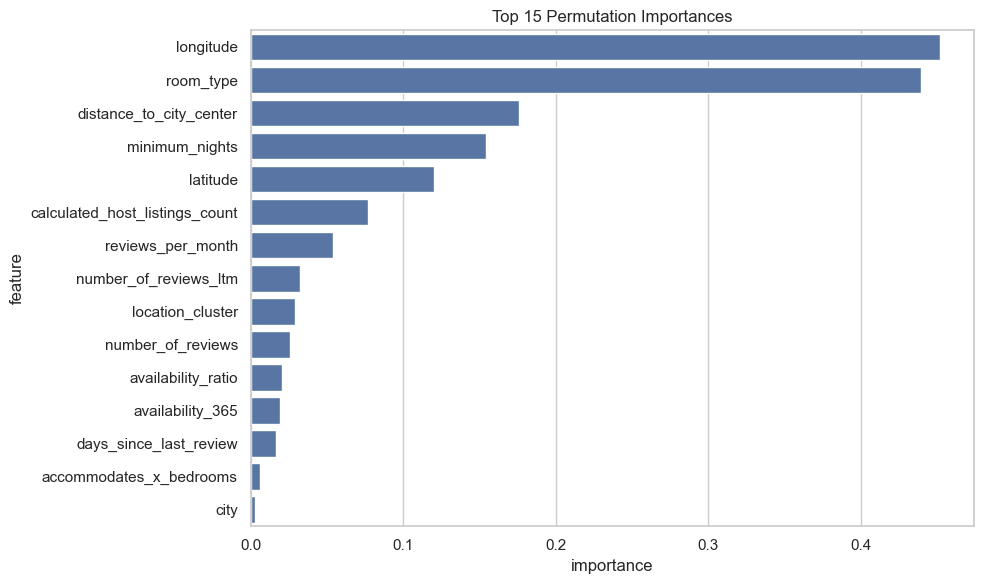

In [81]:
# =========================================
# 20. PERMUTATION IMPORTANCE
# =========================================
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Permutation Importances")
plt.tight_layout()
plt.show()


 <h3>

 11) Conclusion

 </h3>

 <p>

 This project developed machine learning models to predict Airbnb listing prices across Columbus,

 Nashville, and Prague. After cleaning the data, engineering features, and comparing multiple

 models, the final tuned models achieved strong predictive performance.

 </p>

 <p>

 The results substantially improved over the baseline model, showing that the selected features and

 modeling pipeline capture important pricing patterns. Location-based variables, room type, review

 information, and engineered density features were among the most useful predictors.

 </p>

 <p>

 Overall, the project demonstrates that machine learning methods can predict Airbnb prices with

 strong accuracy across multiple cities. Future improvements could include seasonal features,

 calendar availability patterns, or textual review information.

 </p>

In [82]:
mean_price = np.expm1(y_test).mean()
relative_error = ensemble_mae / mean_price

print("Mean price:", mean_price)
print("Relative error:", relative_error)

Mean price: 153.19603717077314
Relative error: 0.3009957307554098
